### Strategy to Boost Supermarket Sales in January

As the manager of a supermarket in Surabaya, I find myself at a crossroads as we step into new year. The new year has just begun, and I am eager to understand how my supermarket has been performing. My office is filled with stacks of transaction data from our customers, brimming with numbers, percentages, and seemingly endless combinations of products. Yet, I feel lost amidst the overwhelming data.

The challenge is clear: I need **insights on what is truly happening in my supermarket**. What are the purchasing patterns of my customers? Which products are flying off the shelves, and which ones are barely noticed? More importantly, **how can I use this information to optimize the layout of the store and boost sales this year**?

In this year, **the store layout is the first thing I want to focus on**. Customers are navigating through the aisles, but I want to ensure they’re being guided to the right places. I wonder: Should I place complementary products closer together? Should I create specific zones to attract customers? For instance, should shampoos be next to toothpaste or near body soaps? Should snacks and drinks be closer together to encourage impulse buys?

The only thing I have right now is the [raw transaction data](https://raw.githubusercontent.com/NathaliaMinoque/datasets/refs/heads/main/Supermarket-January-2017.xlsx) or you can just use this link https://raw.githubusercontent.com/NathaliaMinoque/datasets/refs/heads/main/Supermarket-January-2017.xlsx. It tells me what customers bought, but I need help deciphering it. **Are there certain product combinations that people frequently buy together?** For example, do people who buy detergents also pick up fabric softeners? Do snacks and beverages have a strong pairing trend?

I need your expertise to dig into this data and uncover patterns. Once we understand what products customers often buy together, I can rearrange the store layout to make it more intuitive and appealing. This way, I can improve the shopping experience for my customers while also increasing the chances of cross-selling and boosting sales.

Let’s uncover the story behind the numbers and make data-driven decisions that will set my supermarket up for success in this new year. Help me turn this chaotic dataset into a clear strategy that drives results!

#### Scoring Rubric (Total 100 points)




1.   Class Attendance: 0 / 10

2.   On-time Submission:  0 / 10

3.   EDA Quality & Visualisations:
*   Correct loading and checking of data: 0 / 5
*   Meaningful descriptive stats: 0 / 5
*   At least 2 clear plots with short interpretations: 0 / 5 / 10

4.   Data Preprocessing & Basket Creation
*   Proper column selection and cleaning decisions explained: 0 / 10
*   Correct aggregation to transaction level and one-hot encoding: 0 / 10

5.   ARM Implementation (Apriori Rules)
*   Correct use of apriori() with appropriate min_support values: 0 / 10
*   Correct use of association_rules() with appropriate filtering: 0 / 10

6.   Insights & Business Recommendations
*   Interpretation of rules: 0 / 10
*   Realistic managerial actions:  0 / 10

In [1]:
import pandas as pd
import numpy as np
import requests
from io import BytesIO
from matplotlib import pyplot as plt
from mlxtend.frequent_patterns import apriori, association_rules
import warnings
warnings.filterwarnings(
    "ignore",
    category=DeprecationWarning,
    module="jupyter_client.session"
)

!pip install mlxtend==0.23.1

In [2]:
url = "https://raw.githubusercontent.com/NathaliaMinoque/datasets/refs/heads/main/Supermarket-January-2017.xlsx"
response = requests.get(url)
df = pd.read_excel(BytesIO(response.content))

df.head()

,KD_SBR,TP_TRN,KDSUP,KAS,TRN_DK,GDG,GGD,KDSLS,KEL,ITEM,...,DEP_SWA,GON,KONS,POST_STOK,STATUS,TP_ADJ,USER,TANGGAL,JAM,LAMA_CRD
0,IN,JUL,NaN,6.0,K,A,AREA,NaN,KERTAS,39390.0,...,NaN,NaN,NaN,NaN,NaN,S,MIA,2017-01-02,08:12:02,NaN
1,IN,JUL,NaN,6.0,K,A,AREA,NaN,BTL/DOT,13108.0,...,NaN,NaN,NaN,NaN,NaN,S,MIA,2017-01-02,08:24:51,NaN
2,IN,JUL,NaN,6.0,K,A,AREA,NaN,MUSTIKA,5644.0,...,NaN,NaN,NaN,NaN,NaN,S,MIA,2017-01-02,08:28:18,NaN
3,IN,JUL,NaN,6.0,K,A,AREA,NaN,SABUN.C,7273.0,...,NaN,NaN,NaN,NaN,NaN,S,MIA,2017-01-02,08:28:22,NaN
4,IN,JUL,NaN,6.0,K,A,AREA,NaN,LULURMD,12168.0,...,NaN,NaN,NaN,NaN,NaN,S,MIA,2017-01-02,08:28:20,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148489 entries, 0 to 148488
Data columns (total 61 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   KD_SBR      148486 non-null  object        
 1   TP_TRN      148486 non-null  object        
 2   KDSUP       40832 non-null   float64       
 3   KAS         136294 non-null  float64       
 4   TRN_DK      148486 non-null  object        
 5   GDG         148486 non-null  object        
 6   GGD         148486 non-null  object        
 7   KDSLS       0 non-null       float64       
 8   KEL         148486 non-null  object        
 9   ITEM        148486 non-null  float64       
 10  NAMA        148486 non-null  object        
 11  BIN         13586 non-null   float64       
 12  KDBIN       0 non-null       float64       
 13  TGL_TRANS   148486 non-null  datetime64[ns]
 14  NO_BKT      148486 non-null  object        
 15  NO_ORD      0 non-null       float64       
 16  ST

In [4]:
print(df.shape)

(148489, 61)


In [5]:
df.describe()

,KDSUP,KAS,KDSLS,ITEM,BIN,KDBIN,TGL_TRANS,NO_ORD,SLD_AK,SLD_AKG,...,PTS_GDG,PTS_KEL,PTS_ITEM,QTY_PTS,TGL_OLD,FILLER,SUPPLIER,DEP_SWA,TANGGAL,LAMA_CRD
count,40832.000000,136294.000000,0.0,148486.000000,13586.000000,0.0,148486,0.0,11769.000000,9350.000000,...,0.0,0.0,0.0,0.0,8847,1.484860e+05,7264.000000,1668.000000,148486,37.0
mean,650.873384,4.497381,NaN,21322.181445,8.858531,NaN,2017-01-15 21:02:24.159045376,NaN,20.819228,15.819209,...,NaN,NaN,NaN,NaN,2016-12-07 05:29:26.429297920,1.717615e+11,313.185573,1.182854,2017-01-15 21:34:32.486295296,0.0
min,0.000000,1.000000,NaN,1.000000,1.000000,NaN,2017-01-01 00:00:00,NaN,-12.000000,-12.000000,...,NaN,NaN,NaN,NaN,2013-09-24 00:00:00,1.701010e+11,0.000000,1.000000,2017-01-01 00:00:00,0.0
25%,30.000000,3.000000,NaN,5221.000000,6.000000,NaN,2017-01-07 00:00:00,NaN,0.000000,0.000000,...,NaN,NaN,NaN,NaN,2016-12-01 00:00:00,1.701077e+11,8.000000,1.000000,2017-01-07 00:00:00,0.0
50%,999.000000,5.000000,NaN,13839.000000,8.000000,NaN,2017-01-15 00:00:00,NaN,3.000000,2.000000,...,NaN,NaN,NaN,NaN,2016-12-22 00:00:00,1.701160e+11,69.000000,1.000000,2017-01-16 00:00:00,0.0
75%,999.000000,6.000000,NaN,35802.750000,13.000000,NaN,2017-01-25 00:00:00,NaN,13.000000,11.000000,...,NaN,NaN,NaN,NaN,2017-01-05 00:00:00,1.701251e+11,444.000000,1.000000,2017-01-25 00:00:00,0.0
max,1769.000000,15.000000,NaN,700047.000000,19.000000,NaN,2017-01-31 00:00:00,NaN,2663.000000,1748.000000,...,NaN,NaN,NaN,NaN,2017-01-31 00:00:00,7.013157e+11,1769.000000,2.000000,2017-02-01 00:00:00,0.0
std,467.837803,1.906136,NaN,25881.022963,4.537190,NaN,NaN,NaN,70.033381,54.576439,...,NaN,NaN,NaN,NaN,NaN,2.951083e+10,463.993685,0.386662,NaN,0.0


In [6]:
print(df.isna().sum().to_string())


KD_SBR             3
TP_TRN             3
KDSUP         107657
KAS            12195
TRN_DK             3
GDG                3
GGD                3
KDSLS         148489
KEL                3
ITEM               3
NAMA               3
BIN           134903
KDBIN         148489
TGL_TRANS          3
NO_BKT             3
NO_ORD        148489
STS_BYR        12195
SLD_AK        136720
SLD_AKG       139139
QTY                3
HRG_OLD         2787
HRGBL_OLD     139139
HRG_PKK            3
HRG_JUL            3
DISC            1532
DISC1         133794
DISC2         137736
JLH_DIS       148489
JLH_DIS1      148489
JLH_DIS2      148489
HRGJL_OLD     137610
HRGJL1_OLD    139139
HRGJL2_OLD    139139
SUPP_OLD      139139
DISB1_OLD     139139
DISB2_OLD     139139
PPN             1889
PPN_OLD       139139
PPNBM         139139
PPNBM_OLD     139139
JLH_TRANS          3
KET_TRANS          3
PTS_GDG       148489
PTS_KEL       148489
PTS_ITEM      148489
QTY_PTS       148489
TRNBL              3
POST         

In [7]:
# Nilai tiap column

for col in df.columns:
    print(f"=== {col} ===")
    print(df[col].value_counts(dropna=False))
    print("\n")

=== KD_SBR ===
KD_SBR
IN     148486
NaN         3
Name: count, dtype: int64


=== TP_TRN ===
TP_TRN
JUL    136241
TRM      9350
ADJ      1217
REB      1165
MTS       460
REJ        53
NaN         3
Name: count, dtype: int64


=== KDSUP ===
KDSUP
NaN      107657
999.0     21731
30.0       3637
29.0       3561
27.0        835
          ...  
704.0         1
683.0         1
210.0         1
634.0         1
670.0         1
Name: count, Length: 276, dtype: int64


=== KAS ===
KAS
3.0     34197
7.0     29356
5.0     22081
4.0     19171
6.0     17009
1.0     14390
NaN     12195
15.0       90
Name: count, dtype: int64


=== TRN_DK ===
TRN_DK
K      138356
D       10130
NaN         3
Name: count, dtype: int64


=== GDG ===
GDG
A      148486
NaN         3
Name: count, dtype: int64


=== GGD ===
GGD
AREA    148317
RTR        169
NaN          3
Name: count, dtype: int64


=== KDSLS ===
KDSLS
NaN    148489
Name: count, dtype: int64


=== KEL ===
KEL
SUSU KT    8523
MIE        6788
PAMPERS    6384
SA

In [8]:
print(df.columns.tolist())

['KD_SBR', 'TP_TRN', 'KDSUP', 'KAS', 'TRN_DK', 'GDG', 'GGD', 'KDSLS', 'KEL', 'ITEM', 'NAMA', 'BIN', 'KDBIN', 'TGL_TRANS', 'NO_BKT', 'NO_ORD', 'STS_BYR', 'SLD_AK', 'SLD_AKG', 'QTY', 'HRG_OLD', 'HRGBL_OLD', 'HRG_PKK', 'HRG_JUL', 'DISC', 'DISC1', 'DISC2', 'JLH_DIS', 'JLH_DIS1', 'JLH_DIS2', 'HRGJL_OLD', 'HRGJL1_OLD', 'HRGJL2_OLD', 'SUPP_OLD', 'DISB1_OLD', 'DISB2_OLD', 'PPN', 'PPN_OLD', 'PPNBM', 'PPNBM_OLD', 'JLH_TRANS', 'KET_TRANS', 'PTS_GDG', 'PTS_KEL', 'PTS_ITEM', 'QTY_PTS', 'TRNBL', 'POST', 'TGL_OLD', 'FILLER', 'SUPPLIER', 'DEP_SWA', 'GON', 'KONS', 'POST_STOK', 'STATUS', 'TP_ADJ', 'USER', 'TANGGAL', 'JAM', 'LAMA_CRD']


## EDA

In [59]:
df_stats = df[df['TP_TRN'] == 'JUL']

print("\n=== STATISTIK DESKRIPTIF (Penjualan Januari) ===")
print(f"Total Transaksi Penjualan : {df_stats['NO_BKT'].nunique()}")
print(f"Total Produk Terjual (Qty) : {df_stats['QTY'].sum():,.0f}")
print(f"Total Kategori Unik        : {df_stats['KEL'].nunique()}")
print(f"Periode Data               : {df_stats['TGL_TRANS'].min()} s.d {df_stats['TGL_TRANS'].max()}")


=== STATISTIK DESKRIPTIF (Penjualan Januari) ===
Total Transaksi Penjualan : 35344
Total Produk Terjual (Qty) : 230,695
Total Kategori Unik        : 243
Periode Data               : 2017-01-01 00:00:00 s.d 2017-01-31 00:00:00


### Plot 1: Top 10 Kategori Terlaris (Pareto Principle)

/tmp/ipython-input-40564572.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_categories.index, x=top_categories.values, palette='viridis')


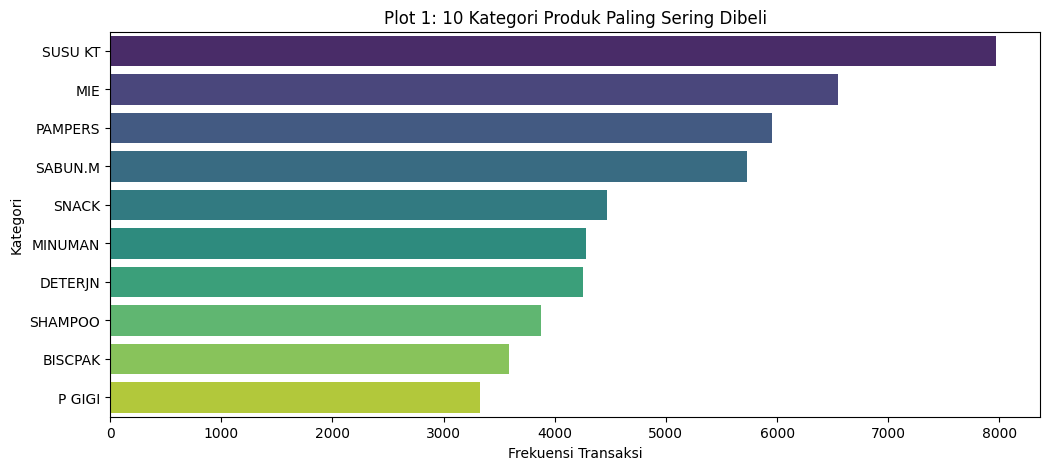

In [60]:
top_categories = df_stats['KEL'].value_counts().head(10)

plt.figure(figsize=(12, 5))
sns.barplot(y=top_categories.index, x=top_categories.values, palette='viridis')
plt.title('Plot 1: 10 Kategori Produk Paling Sering Dibeli')
plt.xlabel('Frekuensi Transaksi')
plt.ylabel('Kategori')
plt.show()

Grafik tersebut menunjukkan sepuluh kategori produk dengan frekuensi transaksi tertinggi pada bulan Januari. Kategori SUSU KT menempati posisi pertama dengan jumlah pembelian yang paling besar, menandakan bahwa produk susu terutama susu anak menjadi kebutuhan utama konsumen dan dibeli secara rutin. Di posisi berikutnya terdapat kategori MIE dan PAMPERS, yang juga mencatat frekuensi transaksi tinggi. Hal ini menggambarkan bahwa makanan instan serta kebutuhan bayi merupakan produk yang sangat diminati dan memiliki perputaran cepat. Kategori SABUN.M, SNACK, dan MINUMAN turut menempati urutan atas, menunjukkan bahwa kebutuhan sehari-hari seperti sabun mandi, makanan ringan, dan minuman menjadi bagian konsisten dari konsumsi pelanggan. Sementara itu, kategori DETERJN, SHAMPOO, BISCPAK, dan P GIGI juga mencatat pembelian yang cukup signifikan, menunjukkan bahwa produk perawatan diri dan kebutuhan rumah tangga tetap menjadi komponen penting dalam belanja konsumen. Secara keseluruhan, pola ini memperlihatkan dominasi produk kebutuhan harian dan keluarga, terutama yang berkaitan dengan anak, kebersihan rumah, dan konsumsi cepat saji.

### Plot 2: Tren Transaksi Harian

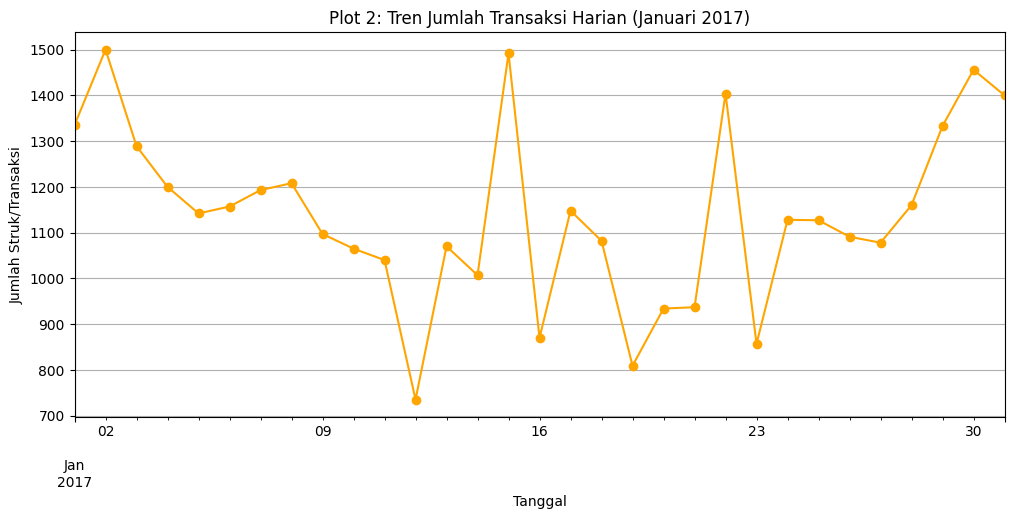

Interpretasi Plot 2: Terlihat pola fluktuasi mingguan. Puncak transaksi sering terjadi di awal minggu/tahun baru. Pastikan stok barang komplementer (hasil analisis nanti) siap sebelum tanggal puncak.


In [61]:
daily_sales = df_stats.groupby('TGL_TRANS')['NO_BKT'].nunique()

plt.figure(figsize=(12, 5))
daily_sales.plot(kind='line', marker='o', color='orange')
plt.title('Plot 2: Tren Jumlah Transaksi Harian (Januari 2017)')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Struk/Transaksi')
plt.grid(True)
plt.show()
print("Interpretasi Plot 2: Terlihat pola fluktuasi mingguan. Puncak transaksi sering terjadi di awal minggu/tahun baru. Pastikan stok barang komplementer (hasil analisis nanti) siap sebelum tanggal puncak.")

Grafik tersebut memperlihatkan tren jumlah transaksi harian sepanjang bulan Januari 2017. Secara keseluruhan, pola transaksi menunjukkan fluktuasi yang cukup signifikan dari hari ke hari. Pada awal bulan, transaksi berada pada level tinggi dan sempat mencapai puncaknya sekitar tanggal 2, sebelum mengalami penurunan bertahap hingga mencapai titik terendah pada sekitar tanggal 12. Setelah itu, terjadi lonjakan yang sangat tajam pada tanggal 15, menunjukkan adanya peningkatan aktivitas belanja yang besar pada hari tersebut. Pola yang sama kembali terjadi pada tanggal 22, di mana transaksi melonjak setelah periode penurunan beberapa hari sebelumnya. Memasuki akhir bulan, tren transaksi kembali meningkat secara konsisten, ditandai dengan dua puncak besar pada tanggal 29 dan 30. Variasi yang naik-turun ini mengindikasikan adanya faktor musiman atau perilaku belanja tertentu yang membuat jumlah transaksi tidak stabil, seperti akhir pekan, awal bulan, atau tanggal-tanggal khusus yang mendorong peningkatan pembelian. Secara keseluruhan, bulan Januari menunjukkan dinamika transaksi yang aktif dengan beberapa puncak penjualan yang menonjol.

## Encoding

In [49]:
df_clean = df.copy()

# FILTER TRANSAKSI
# Mengambil hanya 'JUL' (Jual). Transaksi 'TRM' (Terima), 'ADJ' (Adjusment), dll dibuang
# karena tidak mencerminkan perilaku belanja konsumen kita hanya perlu transaksi yang menjual.
df_clean = df_clean[df_clean['TP_TRN'] == 'JUL']

# B. SELEKSI KOLOM
# Memilih kolom 'KEL' (Kategori) daripada 'NAMA' (Item Spesifik).
# Untuk mengatasi masalah 'Data Sparsity' & varian produk (beda warna/rasa).
# Manajer membutuhkan strategi 'Zoning/Lorong' (Macro Layout), bukan penataan rak per item kecil.
df_clean = df_clean[['NO_BKT', 'KEL', 'QTY', 'TGL_TRANS']]

# Rename agar konsisten
df_clean.rename(columns={'KEL': 'KATEGORI'}, inplace=True)

# C. DATA CLEANING
df_clean.dropna(subset=['NO_BKT', 'KATEGORI'], inplace=True) # Hapus null
df_clean['KATEGORI'] = df_clean['KATEGORI'].str.strip()      # Hapus spasi berlebih
df_clean = df_clean[df_clean['QTY'] > 0]                     # Hapus retur (minus)

df_clean.head()

,NO_BKT,KATEGORI,QTY,TGL_TRANS
0,060102001,KERTAS,2.0,2017-01-02
1,060102002,BTL/DOT,1.0,2017-01-02
2,060102003,MUSTIKA,1.0,2017-01-02
3,060102003,SABUN.C,1.0,2017-01-02
4,060102003,LULURMD,1.0,2017-01-02


### Alasan Pemilihan Fitur (Feature Selection Rationale)


Dari total 61 variabel yang tersedia dalam dataset transaksi mentah, kami melakukan proses seleksi fitur (feature selection) yang ketat dengan mempertahankan empat atribut kunci: NO_BKT, KEL, QTY, dan TGL_TRANS. Keputusan ini diambil untuk mengeliminasi noise data (seperti informasi kasir, jam transaksi, dan harga) yang tidak relevan dengan tujuan analisis tata letak (layout).

Secara spesifik, NO_BKT (Nomor Bukti) digunakan sebagai unique identifier untuk mengelompokkan item ke dalam satu keranjang (basket), yang merupakan syarat mutlak algoritma asosiasi. Kami memilih menggunakan KEL (Kategori Produk) sebagai unit analisis bukan nama item spesifik untuk mengatasi masalah data sparsity dan fragmentasi produk akibat varian warna atau rasa. Pendekatan kategori ini memungkinkan kami menghasilkan strategi Macro Layout (Zoning Lorong) yang lebih strategis dan mudah dieksekusi oleh manajemen. Terakhir, variabel QTY digunakan sebagai filter validasi untuk memastikan hanya transaksi penjualan riil (bukan retur/batal) yang dianalisis, sementara TGL_TRANS berfungsi untuk menjaga integritas periode data analisis (Januari 2017).

## ARM Implementation (Apriori Rules)

In [56]:
from mlxtend.frequent_patterns import apriori, association_rules

# Membuat Pivot Table (Keranjang Belanja)
# Baris = No Struk (Transaksi), Kolom = Kategori Produk
basket_cat = (df_clean.groupby(['NO_BKT', 'KATEGORI'])['QTY']
              .sum().unstack().reset_index().fillna(0)
              .set_index('NO_BKT'))

# One-Hot Encoding (Mengubah jumlah barang menjadi 0 atau 1)
# Kita hanya ingin tahu status "Dibeli" atau "Tidak", kuantitas tidak relevan untuk pola asosiasi.
def encode_units(x):
    if x <= 0: return 0
    if x >= 1: return 1

basket_sets_cat = basket_cat.map(encode_units).astype('bool')

# Menghapus kolom yang tidak berguna jika ada (Postage/Biaya kirim)
if 'POSTAGE' in basket_sets_cat.columns:
    basket_sets_cat.drop('POSTAGE', inplace=True, axis=1)

print(f"Ukuran Matrix Kategori: {basket_sets_cat.shape}")

# Jalankan Algoritma Apriori
# min_support=0.03 artinya kombinasi kategori bakal muncul di minimal 3% total struk
frequent_itemsets = apriori(basket_sets_cat, min_support=0.03, use_colnames=True)

# Buat Aturan Asosiasi
# metric="lift" > 1.1 untuk mencari hubungan yang kuat
rules_cat = association_rules(frequent_itemsets, metric="lift", min_threshold=1.1)

# Tampilkan Hasil Terbaik ik ik ik ik RAWRRRRR
rules_sorted_cat = rules_cat.sort_values(['lift', 'confidence'], ascending=[False, False])

print("\n=== REKOMENDASI ZONING / LAYOUT LORONG ===")
print("Jika pelanggan masuk ke lorong A, arahkan mereka ke lorong B:")
display(rules_sorted_cat[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

Ukuran Matrix Kategori: (35344, 243)

=== REKOMENDASI ZONING / LAYOUT LORONG ===
Jika pelanggan masuk ke lorong A, arahkan mereka ke lorong B:


,antecedents,consequents,support,confidence,lift
1,(P GIGI),(SABUN.M),0.041818,0.539023,6.019341
0,(SABUN.M),(P GIGI),0.041818,0.466983,6.019341
3,(P GIGI),(SHAMPOO),0.038677,0.498541,5.958891
2,(SHAMPOO),(P GIGI),0.038677,0.462293,5.958891
4,(SHAMPOO),(SABUN.M),0.040375,0.482584,5.389080
5,(SABUN.M),(SHAMPOO),0.040375,0.450869,5.389080


In [57]:
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.1)

# Jaccard Index
rules['jaccard'] = rules['support'] / (rules['antecedent support'] + rules['consequent support'] - rules['support'])

# Confidence Backwards (B -> A) untuk perhitungan Kulczynski
confidence_b_to_a = rules['support'] / rules['consequent support']

# Kulczynski
rules['kulczynski'] = 0.5 * (rules['confidence'] + confidence_b_to_a)

# Representativity (Set 1.0)
rules['representativity'] = 1.0

# Certainty
rules['certainty'] = rules['confidence']

# Zhang's Metric
numerator = rules['lift'] - 1
denominator = np.maximum(rules['consequent support'] / rules['antecedent support'],
                         rules['antecedent support'] / rules['consequent support']) - 1
rules['zhangs_metric'] = numerator / denominator

# FORMATTING & SORTING
# Urutkan berdasarkan Lift tertinggi
rules_sorted = rules.sort_values(by="lift", ascending=False)

# Reset index
rules_sorted = rules_sorted.reset_index(drop=True)

# Ubah format frozenset menjadi list biasa
rules_sorted['antecedents'] = rules_sorted['antecedents'].apply(lambda x: list(x))
rules_sorted['consequents'] = rules_sorted['consequents'].apply(lambda x: list(x))

# MENAMPILKAN HASIL AKHIR
target_columns = [
    'antecedents', 'consequents', 'antecedent support', 'consequent support',
    'support', 'confidence', 'lift',
    'representativity', 'leverage', 'conviction',
    'zhangs_metric', 'jaccard', 'certainty', 'kulczynski'
]

print("\n=== ADVANCED ASSOCIATION RULES METRICS (FINAL REPORT) ===")
print("Rekomendasi Strategi Layout Berdasarkan Metrik Lengkap:")
display(rules_sorted[target_columns].head(10))


=== ADVANCED ASSOCIATION RULES METRICS (FINAL REPORT) ===
Rekomendasi Strategi Layout Berdasarkan Metrik Lengkap:


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,[P GIGI],[SABUN.M],0.077580,0.089548,0.041818,0.539023,6.019341,1.0,0.034870,1.975046,32.536723,0.333710,0.539023,0.503003
1,[SABUN.M],[P GIGI],0.089548,0.077580,0.041818,0.466983,6.019341,1.0,0.034870,1.730562,32.536723,0.333710,0.466983,0.503003
2,[SHAMPOO],[P GIGI],0.083663,0.077580,0.038677,0.462293,5.958891,1.0,0.032186,1.715468,63.243158,0.315559,0.462293,0.480417
3,[P GIGI],[SHAMPOO],0.077580,0.083663,0.038677,0.498541,5.958891,1.0,0.032186,1.827342,63.243158,0.315559,0.498541,0.480417
4,[SHAMPOO],[SABUN.M],0.083663,0.089548,0.040375,0.482584,5.389080,1.0,0.032883,1.759611,62.396681,0.303940,0.482584,0.466726
5,[SABUN.M],[SHAMPOO],0.089548,0.083663,0.040375,0.450869,5.389080,1.0,0.032883,1.668703,62.396681,0.303940,0.450869,0.466726


## Insights & Business Recommendations

### 1. Interpretasi Aturan Asosiasi (Interpretation of Rules)


Berdasarkan hasil analisis Apriori, teridentifikasi sebuah "Kluster Kebersihan Harian" (Daily Hygiene Cluster) yang memiliki hubungan statistik sangat ekstrem. Tiga kategori utama yang saling terikat kuat adalah: Pasta Gigi (P GIGI), Sabun Mandi (SABUN.M), dan Shampoo (SHAMPOO).
Berikut adalah interpretasi mendalam dari Top Rules yang dihasilkan:

- Dominasi Aturan [P GIGI] -> [SABUN.M]:
  - Lift 6.02 (Sangat Tinggi): Nilai ini luar biasa tinggi. Artinya, pelanggan yang membeli Pasta Gigi memiliki kecenderungan 6 kali lipat lebih besar untuk membeli Sabun Mandi dibandingkan pelanggan acak. Ini bukan kebetulan, melainkan satu paket kebutuhan.
  - Confidence 54%: Lebih dari separuh (54%) kejadian pembelian pasta gigi pasti disertai pembelian sabun mandi dalam satu struk.
  - Kulczynski 0.50: Menunjukkan hubungan timbal balik yang seimbang (orang beli sabun ingat pasta gigi, dan sebaliknya).

- Segitiga Emas (The Golden Triangle):
  - Data menunjukkan hubungan silang yang konsisten:

    - SHAMPOO & P GIGI (Lift 5.96)

    - SHAMPOO & SABUN.M (Lift 5.39)

  - Insight: Ketiga barang ini membentuk ekosistem produk yang tidak terpisahkan. Pelanggan memandang ketiga barang ini sebagai satu kesatuan "Ritual Mandi".

### 2. Rekomendasi Manajerial Konkret (Realistic Managerial Actions)


Berdasarkan data "Kluster Kebersihan" di atas, berikut adalah 3 strategi aksi (Actionable Strategy) untuk diimplementasikan di toko bulan ini:

Strategi 1: ZONING "ONE-STOP BATHROOM SHOP" (Re-Layout)
Masalah: Saat ini mungkin lorong Pasta Gigi, Sabun, dan Shampoo terpisah atau terlalu panjang, membuat pelanggan harus berjalan jauh. Aksi:

1. Gabungkan Lorong: Wajib menempatkan rak Pasta Gigi, Sabun Mandi, dan Shampoo di satu lorong yang sama dan bersebelahan (Side-by-side).
2. Urutan Rak: Gunakan urutan logis berdasarkan data Lift tertinggi: [ Rak Pasta Gigi ] -- [ Rak Sabun Mandi ] -- [ Rak Shampoo ]
3. Tujuan: Memudahkan pelanggan mengambil ketiganya sekaligus tanpa berpikir panjang, yang akan menjaga nilai Confidence tetap tinggi.

Strategi 2: PAKET BUNDLING "TOILETRIES HEMAT"
Dasar Data: Karena Lift > 5 dan Confidence ~50%, artinya pelanggan memang butuh ketiganya. Aksi:

1. Buat paket bundling fisik yang berisi 1 Pasta Gigi + 1 Sabun Cair + 1 Shampoo.
2. Berikan harga khusus (misal: "Beli Paket Mandi Hemat, Lebih Murah Rp 2.000").
3. Tujuan: Mengonversi 46-50% pelanggan yang belum membeli pasangannya (sisa dari confidence) agar membeli paket lengkap, sehingga meningkatkan Basket Size.

Strategi 3: CROSS-SELLING DI KASIR & UJUNG LORONG
Dasar Data: Produk ini adalah kebutuhan pokok (High Demand). Aksi:

1. Tempatkan "Travel Size" (ukuran kecil) dari Pasta Gigi dan Sabun di rak display dekat kasir (Check-out Counter).
2. Pasang Shelf Talker (tulisan pengingat) di rak Shampoo bertuliskan: "Sudah ambil Pasta Gigi & Sabun-nya?"
3. Tujuan: Menangkap pembelian impulsif bagi pelanggan yang mungkin lupa mengambil salah satu dari item "Segitiga Emas" ini saat di lorong utama.

Kesimpulan Akhir: Data membuktikan bahwa Pasta Gigi, Sabun, dan Shampoo tidak boleh dipisahkan. Penataan ulang (Re-layout) yang mendekatkan ketiga kategori ini diprediksi akan meningkatkan efisiensi belanja pelanggan dan memaksimalkan penjualan kategori Personal Care secara signifikan.